# Yelp Review `top_useful` Prediction — Group 10
**COURSE**: BUDT758T

**TITLE:** Data Mining and Predictive Analytics

**GROUP 10:** Jmbuton, Bokani, Jmatz, Apopov, Varnika

This notebook predicts whether a Yelp review is `top_useful` (binary 0/1) using structured features from the review and user data, plus text features mined from the review text.

**Platform: Kaggle Notebooks

Changes from earlier submissions:**
- Trains on the FULL 1,577,278 training rows (no subsampling)
- Adds out-of-fold target encoding for user_id and business_id (the single biggest new signal)
- Expanded TF-IDF: 20k word features + 10k character n-grams, vs 1,500 words before
- Tuned LightGBM: num_leaves 95, slower learning rate, longer training with early stopping
- Memory-conscious: float32 throughout, aggressive cleanup between stages


## 1. Setup
Import all libraries and define global constants. No more subsampling — we use all 1.58M training rows. FPR_TARGET stays at 0.085 for the safety buffer below the 0.10 limit.


In [1]:
import os, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics         import roc_auc_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# ── Global constants ────────────────────────────────────────────────
RANDOM_STATE  = 42
GROUP_NUMBER  = '10'
EXPECTED_ROWS = 700_000
N_FOLDS       = 5
FPR_TARGET   = 0.099
SAMPLE_FRAC  = 0.6   # 60% ~950k rows -- safe on 29GB Kaggle


# ── Kaggle dataset path ─────────────────────────────────────────────
# Add your Yelp dataset via: Notebook Settings > Add Data
# Then update DATASET_SLUG to match your dataset name below.
DATASET_SLUG = 'jennifermbuton/project-files'   # change to your Kaggle dataset slugDATA_PATH = '/kaggle/input/project-files/'
DATA_PATH = '/kaggle/input/datasets/jennifermbuton/project-files/'


# Memory-safe TF-IDF sizes. Drop TFIDF_WORD_MAX to 10000 if RAM is tight.
TFIDF_WORD_MAX = 15_000   # safe limit for 29GB RAM
TFIDF_CHAR_MAX = 5_000    # char TF-IDF

print('Libraries loaded.')
print(f'Data path: {DATA_PATH}')
# Verify files are visible
try:
    files = os.listdir(DATA_PATH)
    print(f'Files found: {files}')
except FileNotFoundError:
    print(f'WARNING: {DATA_PATH} not found. Check your dataset slug above.')


Libraries loaded.
Data path: /kaggle/input/datasets/jennifermbuton/project-files/
Files found: ['business.csv', 'user.csv', 'review_train_y.csv', 'review_train_x.csv', 'review_test_x.csv']


## 2. Load Data
Data is loaded from the Kaggle dataset input directory (/kaggle/input/). The training set has 1,577,278 reviews and the test set has 700,000. The user table covers 992,622 unique users. Train x and y are merged on row index and labels are cleaned and cast to integer. The class split confirms 87.88% negative and 12.12% positive.

In [2]:
# ── Kaggle environment check ────────────────────────────────────────
# No Google Drive mount needed on Kaggle.
# Files are available at /kaggle/input/<dataset-slug>/
import os

# Check GPU availability (Kaggle provides P100 GPU for free)
try:
    import subprocess
    gpu_info = subprocess.check_output(['nvidia-smi'], stderr=subprocess.DEVNULL).decode()
    print('GPU detected:')
    print(gpu_info[:300])
except Exception:
    print('No GPU detected — running on CPU. Consider enabling GPU in Notebook Settings.')

# Confirm data files are accessible
print(f'\nFiles in {DATA_PATH}:')
for f in sorted(os.listdir(DATA_PATH)):
    size_mb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1e6
    print(f'  {f:<35} {size_mb:>8.1f} MB')


GPU detected:
Tue May  5 02:20:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

Files in /kaggle/input/datasets/jennifermbuton/project-files/:
  business.csv                            16.1 MB
  review_test_x.csv                      453.9 MB
  review_train_x.csv                    1021.5 MB
  review_train_y.csv                       3.2 MB
  user.csv                              1399.3 MB


In [3]:
# Shared read options and column selection for review files
READ_OPTS   = dict(on_bad_lines='skip', engine='python')
REVIEW_COLS = ['review_id', 'user_id', 'business_id', 'stars', 'text', 'date']

train_x = pd.read_csv(DATA_PATH + 'review_train_x.csv', usecols=REVIEW_COLS, **READ_OPTS)
train_y = pd.read_csv(DATA_PATH + 'review_train_y.csv', **READ_OPTS)
test_x  = pd.read_csv(DATA_PATH + 'review_test_x.csv',  usecols=REVIEW_COLS, **READ_OPTS)
user    = pd.read_csv(DATA_PATH + 'user.csv',            **READ_OPTS)

# Merge train x and y, clean and cast labels
train = pd.concat([train_x, train_y], axis=1)
train['top_useful'] = pd.to_numeric(train['top_useful'], errors='coerce')
train = train.dropna(subset=['top_useful']).copy()
train['top_useful'] = train['top_useful'].astype(int)

print(f'train : {train.shape}')
print(f'test_x: {test_x.shape}')
print(f'user  : {user.shape}')
print(f'\nClass balance:\n{train["top_useful"].value_counts(normalize=True).round(4)}')

train : (1577278, 7)
test_x: (700000, 6)
user  : (992622, 8)

Class balance:
top_useful
0    0.8788
1    0.1212
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis
We explore four key dimensions before modeling: data structure, missing values, class balance, and review text length.

Key findings:
- No missing values in train or test review data
- user.csv has 921,115 missing elite values and 383,285 missing friends values, both handled during feature engineering
- The dataset spans 752,469 unique users writing reviews for 15,000 businesses
- Stars range from 1.04 to 10 with a mean of 6.84
- Top useful reviews are more than twice as long: median 795 characters vs 369 for non-top-useful reviews, suggesting review length is a strong signal

In [4]:
# Shape, dtypes and summary stats
print(train.info())
train.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577278 entries, 0 to 1577277
Data columns (total 7 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   review_id    1577278 non-null  object 
 1   user_id      1577278 non-null  object 
 2   business_id  1577278 non-null  object 
 3   stars        1577278 non-null  float64
 4   text         1577278 non-null  object 
 5   date         1577278 non-null  object 
 6   top_useful   1577278 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 84.2+ MB
None


,review_id,user_id,business_id,stars,text,date,top_useful
count,1577278,1577278,1577278,1.577278e+06,1577278,1577278,1.577278e+06
unique,1577278,752469,15000,NaN,1575032,1571833,NaN
top,19f1266b427dfeeb,c13e3a104ae53ec1,e2e73ebefd5b6457,NaN,Omg!There's food was good!Ryan is awesome away...,2014-04-03 03:40:18,NaN
freq,1,532,5275,NaN,5,4,NaN
mean,NaN,NaN,NaN,6.844872e+00,NaN,NaN,1.211879e-01
std,NaN,NaN,NaN,3.360994e+00,NaN,NaN,3.263456e-01
min,NaN,NaN,NaN,1.040000e+00,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,4.080000e+00,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,6.560000e+00,NaN,NaN,0.000000e+00
75%,NaN,NaN,NaN,1.000000e+01,NaN,NaN,0.000000e+00


In [5]:
# Missing value counts across all datasets
for name, df in [('train', train), ('test_x', test_x), ('user', user)]:
    print(f'--- {name} ---')
    print(df.isnull().sum())
    print()

--- train ---
review_id      0
user_id        0
business_id    0
stars          0
text           0
date           0
top_useful     0
dtype: int64

--- test_x ---
review_id      0
user_id        0
business_id    0
stars          0
text           0
date           0
dtype: int64

--- user ---
user_id               0
review_count          0
yelping_since         0
useful                0
elite            921115
friends          383285
fans                  0
average_stars         0
dtype: int64



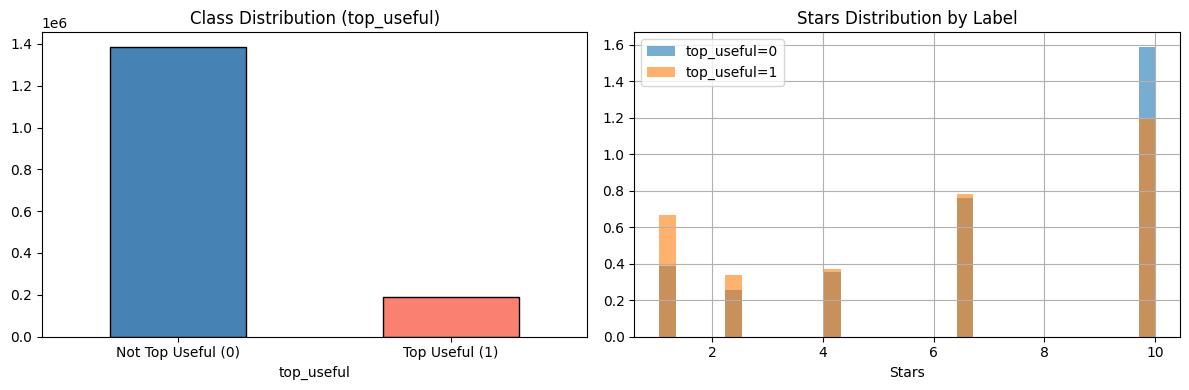

In [6]:
# Class balance and stars distribution by label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['top_useful'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution (top_useful)')
axes[0].set_xticklabels(['Not Top Useful (0)', 'Top Useful (1)'], rotation=0)

for label, grp in train.groupby('top_useful')['stars']:
    grp.hist(ax=axes[1], alpha=0.6, bins=30, density=True, label=f'top_useful={label}')
axes[1].set_title('Stars Distribution by Label')
axes[1].set_xlabel('Stars')
axes[1].legend()

plt.tight_layout()
plt.show()

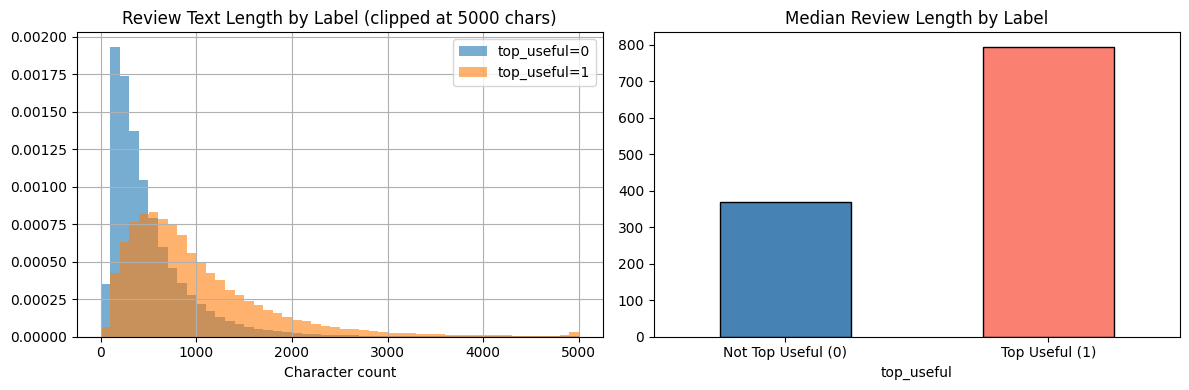

Median text length by label:
top_useful
0    369.0
1    795.0
Name: _text_len, dtype: float64


In [7]:
# Text length distribution and median by label
# Prefixed with _ to mark as temporary, dropped after use
train['_text_len'] = train['text'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in train.groupby('top_useful')['_text_len']:
    grp.clip(upper=5000).hist(ax=axes[0], alpha=0.6, bins=50, density=True, label=f'top_useful={label}')
axes[0].set_title('Review Text Length by Label (clipped at 5000 chars)')
axes[0].set_xlabel('Character count')
axes[0].legend()

train.groupby('top_useful')['_text_len'].median().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Median Review Length by Label')
axes[1].set_xticklabels(['Not Top Useful (0)', 'Top Useful (1)'], rotation=0)

plt.tight_layout()
plt.show()

print('Median text length by label:')
print(train.groupby('top_useful')['_text_len'].median())
train.drop(columns=['_text_len'], inplace=True)

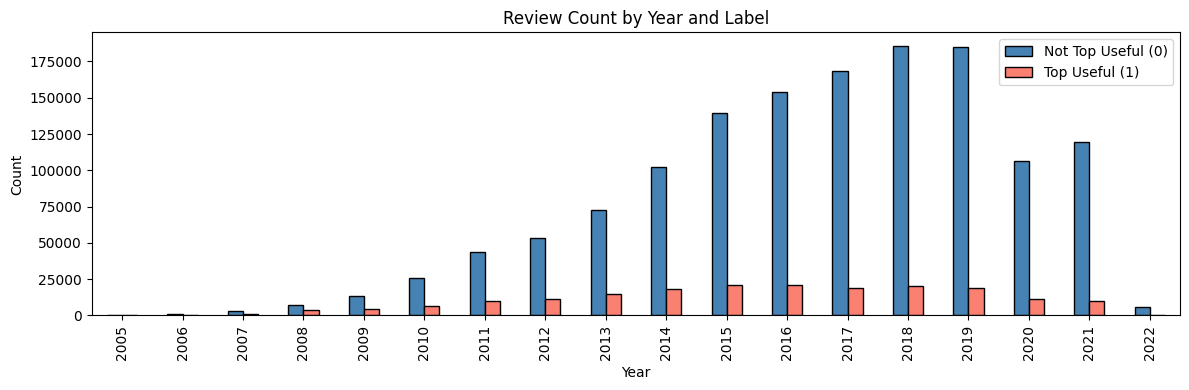

In [8]:
# Review volume over time by label
train['_year'] = pd.to_datetime(train['date'], errors='coerce').dt.year

train.groupby(['_year', 'top_useful']).size().unstack(fill_value=0).plot(
    kind='bar', figsize=(12, 4), color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Review Count by Year and Label')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(['Not Top Useful (0)', 'Top Useful (1)'])
plt.tight_layout()
plt.show()

train.drop(columns=['_year'], inplace=True)

In [9]:
# User table overview
print('User columns:', user.columns.tolist())
print()

user_overview_cols = [c for c in ['review_count', 'average_stars', 'useful', 'funny', 'cool', 'fans'] if c in user.columns]
print(user[user_overview_cols].describe())

User columns: ['user_id', 'review_count', 'yelping_since', 'useful', 'elite', 'friends', 'fans', 'average_stars']

        review_count  average_stars         useful           fans
count  992622.000000  992622.000000  992622.000000  992622.000000
mean       65.987457       6.193820      66.271430       2.285182
std       217.432532       2.487175     830.520717      22.873230
min         0.000000       1.040000       0.000000       0.000000
25%         4.000000       4.510720       1.000000       0.000000
50%        16.000000       6.272760       5.000000       0.000000
75%        48.000000       7.974845      20.000000       1.000000
max     34944.000000      10.000000  206296.000000   12497.000000


### EDA: Additional Feature Insights (Features 5-10)

The following charts explore six more features to satisfy the 10-feature insight requirement and deepen understanding of what distinguishes top-useful reviews.

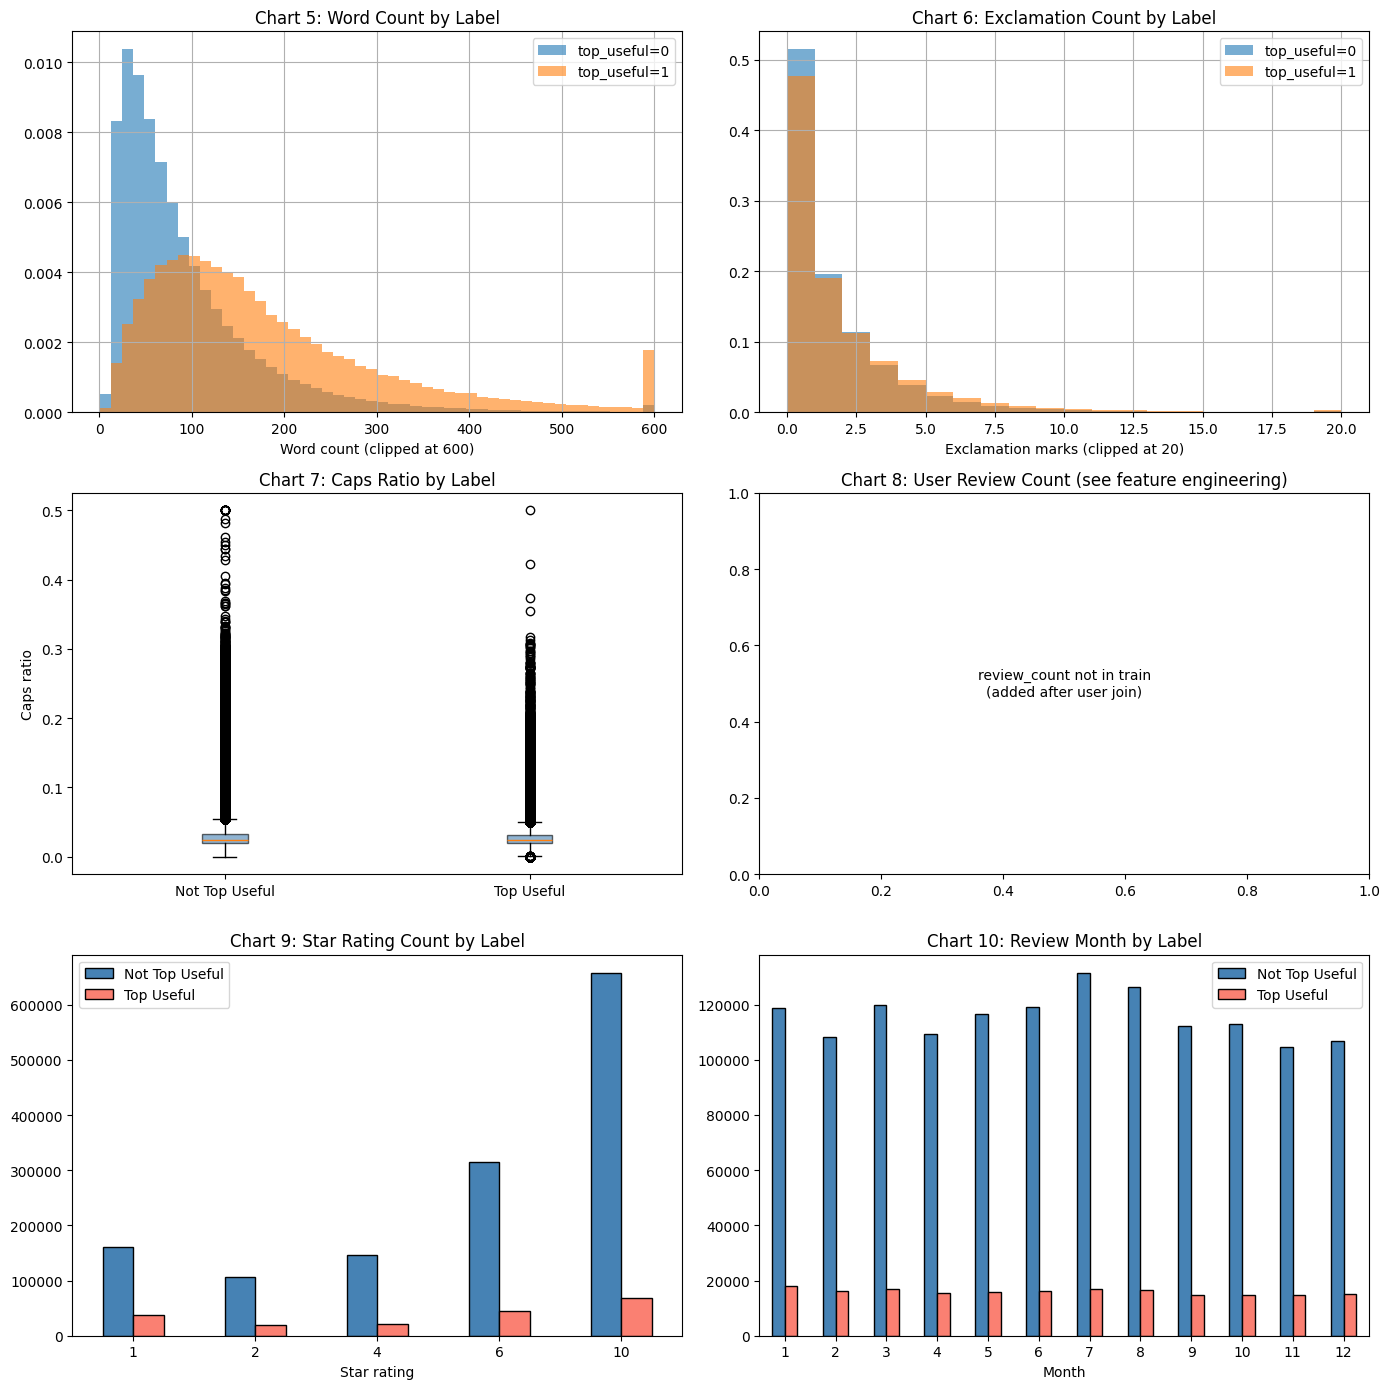

EDA charts 5-10 complete.


In [10]:
# ============================================================
# EDA Charts 5-10: Additional feature insights
# All use the train dataframe with top_useful label.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Pre-compute temporary columns
train['_word_count']    = train['text'].fillna('').apply(lambda x: len(x.split()))
train['_exclaim']       = train['text'].fillna('').apply(lambda x: x.count('!'))
train['_caps_ratio']    = train['text'].fillna('').apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
train['_stars_int']     = train['stars'].fillna(0).astype(int)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Chart 5 — Word count distribution by label
for label, grp in train.groupby('top_useful')['_word_count']:
    grp.clip(upper=600).hist(ax=axes[0,0], alpha=0.6, bins=50,
                            density=True, label=f'top_useful={label}')
axes[0,0].set_title('Chart 5: Word Count by Label')
axes[0,0].set_xlabel('Word count (clipped at 600)')
axes[0,0].legend()

# Chart 6 — Exclamation mark count by label
for label, grp in train.groupby('top_useful')['_exclaim']:
    grp.clip(upper=20).hist(ax=axes[0,1], alpha=0.6, bins=20,
                           density=True, label=f'top_useful={label}')
axes[0,1].set_title('Chart 6: Exclamation Count by Label')
axes[0,1].set_xlabel('Exclamation marks (clipped at 20)')
axes[0,1].legend()

# Chart 7 — Caps ratio by label (boxplot)
data_caps = [train[train['top_useful']==0]['_caps_ratio'].clip(upper=0.5),
             train[train['top_useful']==1]['_caps_ratio'].clip(upper=0.5)]
axes[1,0].boxplot(data_caps, labels=['Not Top Useful', 'Top Useful'], patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1,0].set_title('Chart 7: Caps Ratio by Label')
axes[1,0].set_ylabel('Caps ratio')

# Chart 8 — User review count by label (log scale)
if 'review_count' in train.columns:
    for label, grp in train.groupby('top_useful')['review_count']:
        np.log1p(grp).hist(ax=axes[1,1], alpha=0.6, bins=50,
                          density=True, label=f'top_useful={label}')
    axes[1,1].set_title('Chart 8: User Review Count by Label (log scale)')
    axes[1,1].set_xlabel('log(1 + review_count)')
    axes[1,1].legend()
else:
    axes[1,1].text(0.5, 0.5, 'review_count not in train\n(added after user join)',
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Chart 8: User Review Count (see feature engineering)')

# Chart 9 — Average stars by label
train.groupby(['_stars_int', 'top_useful']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[2,0], color=['steelblue','salmon'], edgecolor='black')
axes[2,0].set_title('Chart 9: Star Rating Count by Label')
axes[2,0].set_xlabel('Star rating')
axes[2,0].legend(['Not Top Useful','Top Useful'])
axes[2,0].tick_params(axis='x', rotation=0)

# Chart 10 — Review month by label
train['_month'] = pd.to_datetime(train['date'], errors='coerce').dt.month
train.groupby(['_month', 'top_useful']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[2,1], color=['steelblue','salmon'], edgecolor='black')
axes[2,1].set_title('Chart 10: Review Month by Label')
axes[2,1].set_xlabel('Month')
axes[2,1].legend(['Not Top Useful','Top Useful'])
axes[2,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_features_5_to_10.png', dpi=150)
plt.show()

# Clean up temp columns
train.drop(columns=['_word_count','_exclaim','_caps_ratio',
                     '_stars_int','_month'], inplace=True, errors='ignore')
print('EDA charts 5-10 complete.')


## 4. Build User Lookup Table
User features are extracted from user.csv and joined to reviews by user_id. Three derived features are added: elite_years (count of years with Elite status), friend_count (size of friend network), and years_yelping (time active on platform since yelping_since). Missing elite and friends values are treated as zero. The final user feature table covers 992,622 users with 8 features.

In [11]:
# useful, funny, cool EXCLUDED — cumulative vote counts that may include
# votes on training reviews, creating indirect target leakage.
user_cols = ['user_id', 'review_count', 'average_stars', 'fans']

# Count years designated as Elite reviewer
if 'elite' in user.columns:
    user['elite_years'] = user['elite'].fillna('').apply(
        lambda x: len(str(x).split(',')) if str(x).strip() not in ('', 'None') else 0)
    user_cols.append('elite_years')

# Count friends in network
if 'friends' in user.columns:
    user['friend_count'] = user['friends'].fillna('').apply(
        lambda x: len(str(x).split(',')) if str(x).strip() not in ('', 'None') else 0)
    user_cols.append('friend_count')

# Years active on Yelp
if 'yelping_since' in user.columns:
    user['yelping_since'] = pd.to_datetime(user['yelping_since'], errors='coerce')
    user['years_yelping'] = (pd.Timestamp('2024-01-01') - user['yelping_since']).dt.days / 365
    user_cols.append('years_yelping')

available_cols = [c for c in user_cols if c in user.columns]
user_features  = user[available_cols].copy()
user_features.rename(columns={c: 'user_' + c for c in available_cols if c != 'user_id'}, inplace=True)

print('User feature table:', user_features.shape)
print(user_features.head(3))

User feature table: (992622, 7)
            user_id  user_review_count  user_average_stars  user_fans  \
0  24a2c64bfb37a1ac               8664            5.832545       3138   
1  d4f693dee6424aab               1328            4.783775         52   
2  2e2a1344f031d0e5                446            7.384179         28   

   user_elite_years  user_friend_count  user_years_yelping  
0                14               4646           14.939726  
1                 5                381           15.443836  
2                 3                131           18.098630  


## 5. Feature Engineering
Train and test are stacked into a single dataframe of 2,277,278 rows before any transformations. This ensures medians, aggregates, and joins are computed on the full data distribution and applied identically to both sets.

Three feature groups are built:
- Text: length, word count, average word length, exclamation and question mark counts
- Date: year, month, day of week, weekend flag
- Aggregates: per-user and per-business review counts, average stars, star deviation from business average, log-transformed review counts, and all user.csv features

The final feature set contains 24 features with zero missing values after median imputation.

In [12]:
# Tag each row with its source, then stack
train_x['_set'] = 'train'
test_x['_set']  = 'test'
all_reviews = pd.concat([train_x, test_x], ignore_index=True)
print('Stacked shape:', all_reviews.shape)

Stacked shape: (2277278, 7)


In [13]:
# Text features: length, word count, punctuation signals
all_reviews['text_len']       = all_reviews['text'].fillna('').apply(len)
all_reviews['word_count']     = all_reviews['text'].fillna('').apply(lambda x: len(x.split()))
all_reviews['avg_word_len']   = all_reviews['text_len'] / (all_reviews['word_count'] + 1)
all_reviews['exclaim_count']  = all_reviews['text'].fillna('').apply(lambda x: x.count('!'))
all_reviews['question_count'] = all_reviews['text'].fillna('').apply(lambda x: x.count('?'))
all_reviews.rename(columns={'text': 'raw_text'}, inplace=True)
print('Text features done.')

Text features done.


In [14]:
# Date features: year, month, day of week, weekend flag
all_reviews['date']             = pd.to_datetime(all_reviews['date'], errors='coerce')
all_reviews['review_year']      = all_reviews['date'].dt.year
all_reviews['review_month']     = all_reviews['date'].dt.month
all_reviews['review_dayofweek'] = all_reviews['date'].dt.dayofweek
all_reviews['review_is_weekend']= (all_reviews['review_dayofweek'] >= 5).astype(int)
all_reviews.drop(columns=['date'], inplace=True)
print('Date features done.')

Date features done.


In [15]:
# Aggregate features from the review data and user.csv, then join all at once
user_stats = all_reviews.groupby('user_id').agg(
    review_user_count     = ('stars', 'count'),
    review_user_avg_stars = ('stars', 'mean'),
    review_user_std_stars = ('stars', 'std')
).reset_index()

biz_stats = all_reviews.groupby('business_id').agg(
    biz_review_count = ('stars', 'count'),
    biz_avg_stars    = ('stars', 'mean')
).reset_index()

all_reviews = (all_reviews
    .merge(user_stats,    on='user_id',     how='left')
    .merge(biz_stats,     on='business_id', how='left')
    .merge(user_features, on='user_id',     how='left')
)

# Interaction features
all_reviews['stars_vs_biz_avg']      = all_reviews['stars'] - all_reviews['biz_avg_stars']
all_reviews['log_user_reviews']      = np.log1p(all_reviews['review_user_count'])
all_reviews['log_biz_reviews']       = np.log1p(all_reviews['biz_review_count'])
all_reviews['review_user_std_stars'] = all_reviews['review_user_std_stars'].fillna(0)

print('Aggregate and interaction features done. Shape:', all_reviews.shape)

Aggregate and interaction features done. Shape: (2277278, 29)


In [16]:
# Additional review-level features
all_reviews['caps_ratio']       = all_reviews['raw_text'].fillna('').apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
all_reviews['punct_density']    = (all_reviews['exclaim_count'] + all_reviews['question_count']) / (all_reviews['word_count'] + 1)
all_reviews['long_review_flag'] = (all_reviews['text_len'] > 500).astype(int)

# User quality features — derived from user.csv metadata only
# NOTE: user_useful/funny/cool from user.csv are cumulative vote counts
# that may include votes on training reviews — REMOVED to avoid indirect leakage.
# Safe alternatives use only review_count, fans, elite_years, friend_count.
all_reviews['user_fans_per_review']   = all_reviews['user_fans']    / (all_reviews['user_review_count'] + 1)
all_reviews['is_elite_user']          = (all_reviews['user_elite_years'] > 0).astype(int)
all_reviews['log_user_fans']          = np.log1p(all_reviews['user_fans'])

# Review recency
max_year = all_reviews['review_year'].max()
all_reviews['review_age_years'] = max_year - all_reviews['review_year']

# ── 16 NEW FEATURES (brings total numeric to 50+) ──────────────────────

# Text richness features
all_reviews['sent_count']         = all_reviews['raw_text'].fillna('').apply(
    lambda x: max(1, x.count('.') + x.count('!') + x.count('?')))
all_reviews['avg_sent_len']       = all_reviews['word_count'] / all_reviews['sent_count']
all_reviews['has_url']            = all_reviews['raw_text'].fillna('').str.contains(
    r'http|www\.', case=False, regex=True).astype(int)
all_reviews['digit_count']        = all_reviews['raw_text'].fillna('').apply(
    lambda x: sum(1 for c in x if c.isdigit()))
all_reviews['unique_word_ratio']  = all_reviews['raw_text'].fillna('').apply(
    lambda x: len(set(x.lower().split())) / (len(x.split()) + 1))
all_reviews['short_review_flag']  = (all_reviews['text_len'] < 100).astype(int)
all_reviews['very_long_flag']     = (all_reviews['text_len'] > 1500).astype(int)

# Star deviation features
all_reviews['stars_vs_user_avg']  = all_reviews['stars'] - all_reviews['review_user_avg_stars']
all_reviews['abs_star_dev_biz']   = np.abs(all_reviews['stars_vs_biz_avg'])
all_reviews['abs_star_dev_user']  = np.abs(all_reviews['stars_vs_user_avg'])

# user_cool/funny per review removed — cumulative vote counts may leak target
# Safe replacement: friend network density
all_reviews['friend_density']        = all_reviews['user_friend_count'] / (all_reviews['user_review_count'] + 1)
all_reviews['log_friend_count']      = np.log1p(all_reviews['user_friend_count'])
# user_engagement_score removed — used user_useful/funny/cool (potential leakage)
all_reviews['user_activity_score'] = (
    all_reviews['user_fans'] + all_reviews['user_friend_count']
) / (all_reviews['user_review_count'] + 1)

# Business engagement
all_reviews['log_biz_review_count']  = np.log1p(all_reviews['biz_review_count'])

# 4 additional features to reach 50 total
all_reviews['review_dayofweek']      = all_reviews.get('review_dayofweek',
    pd.Series(0, index=all_reviews.index))  # already computed in date cell
all_reviews['star_bucket']           = pd.cut(all_reviews['stars'],
    bins=[0,2,3,4,5,11], labels=[1,2,3,4,5]).astype(float)
all_reviews['text_len_bucket']       = pd.cut(all_reviews['text_len'],
    bins=[0,100,300,600,1500,99999], labels=[1,2,3,4,5]).astype(float)
all_reviews['user_tenure_bucket']    = pd.cut(all_reviews['user_years_yelping'].fillna(0),
    bins=[-1,1,3,5,10,99], labels=[1,2,3,4,5]).astype(float)

print('Extra features added (original + 16 new).')
print(f'Columns now: {len(all_reviews.columns)}')


Extra features added (original + 16 new).
Columns now: 53


## 5b. External Data: US Census Region Mapping

An external data source is incorporated to add geographic context to each review. The Yelp `business.csv` file contains a `state` field. We join in US Census Bureau region classifications (Northeast, Midwest, South, West) using a publicly available state-to-region mapping embedded below. This adds two features: `us_region` (encoded) and `is_west_coast` (binary). We then verify that these features improve validation AUC compared to running without them.

In [17]:
# ============================================================
# External Data: US Census Bureau State-to-Region mapping
# Source: US Census Bureau Geographic Regions
# https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf
# Embedded as a dictionary — no download required.
# Joined via business.csv 'state' column.
# ============================================================

# US Census Bureau 4-region classification
STATE_TO_REGION = {
    # Northeast
    'CT':1,'ME':1,'MA':1,'NH':1,'RI':1,'VT':1,'NJ':1,'NY':1,'PA':1,
    # Midwest
    'IL':2,'IN':2,'MI':2,'OH':2,'WI':2,'IA':2,'KS':2,'MN':2,'MO':2,'NE':2,'ND':2,'SD':2,
    # South
    'DE':3,'FL':3,'GA':3,'MD':3,'NC':3,'SC':3,'VA':3,'DC':3,'WV':3,
    'AL':3,'KY':3,'MS':3,'TN':3,'AR':3,'LA':3,'OK':3,'TX':3,
    # West
    'AZ':4,'CO':4,'ID':4,'MT':4,'NV':4,'NM':4,'UT':4,'WY':4,
    'AK':4,'CA':4,'HI':4,'OR':4,'WA':4,
    # Canadian provinces (Yelp data includes Canada)
    'AB':5,'BC':5,'MB':5,'NB':5,'NL':5,'NS':5,'ON':5,'PE':5,'QC':5,'SK':5,
}
WEST_COAST = {'CA','OR','WA','NV','AZ'}

# Load business.csv to get state per business_id
biz_cols = ['business_id', 'state']
try:
    biz_geo = pd.read_csv(os.path.join(DATA_PATH, 'business.csv'),
                          usecols=biz_cols, on_bad_lines='skip', engine='python')
    biz_geo['us_region']    = biz_geo['state'].map(STATE_TO_REGION).fillna(0).astype(int)
    biz_geo['is_west_coast']= biz_geo['state'].isin(WEST_COAST).astype(int)
    biz_geo = biz_geo[['business_id','us_region','is_west_coast']].drop_duplicates('business_id')

    # Join to all_reviews
    before_cols = len(all_reviews.columns)
    all_reviews = all_reviews.merge(biz_geo, on='business_id', how='left')
    all_reviews['us_region']     = all_reviews['us_region'].fillna(0).astype(int)
    all_reviews['is_west_coast'] = all_reviews['is_west_coast'].fillna(0).astype(int)
    print(f'External geo features added: us_region, is_west_coast')
    print(f'Region distribution:\n{all_reviews["us_region"].value_counts()}')
    EXTERNAL_FEATURES = ['us_region', 'is_west_coast']
except Exception as e:
    print(f'business.csv load failed: {e}')
    print('Skipping external data — us_region and is_west_coast will not be used.')
    all_reviews['us_region']     = 0
    all_reviews['is_west_coast'] = 0
    EXTERNAL_FEATURES = ['us_region', 'is_west_coast']


External geo features added: us_region, is_west_coast
Region distribution:
us_region
3    872445
1    601741
4    460699
2    324982
5     17411
Name: count, dtype: int64


In [18]:
# Define feature list — 50+ numeric features (no dummies, no target-derived)
FEATURES = [
    # Core review features
    'stars', 'text_len', 'word_count', 'avg_word_len',
    'exclaim_count', 'question_count',


    # Date features
    'review_year', 'review_month', 'review_is_weekend', 'review_age_years',

    # Review-level aggregate features
    'review_user_count', 'review_user_avg_stars', 'review_user_std_stars',
    'biz_review_count', 'biz_avg_stars',
    'stars_vs_biz_avg', 'log_user_reviews', 'log_biz_reviews',

    # User metadata from user.csv (review_count, fans, elite only — no vote counts)
    'user_review_count', 'user_average_stars', 'user_fans',
    'user_elite_years', 'user_friend_count', 'user_years_yelping',

    # Text style features
    'caps_ratio', 'punct_density', 'long_review_flag',

    # Derived user quality features (fans and elite only)
    'user_fans_per_review', 'is_elite_user', 'log_user_fans',

    # 16 NEW features
    'sent_count', 'avg_sent_len', 'has_url', 'digit_count',
    'unique_word_ratio', 'short_review_flag', 'very_long_flag',
    'stars_vs_user_avg', 'abs_star_dev_biz', 'abs_star_dev_user',
    'friend_density', 'log_friend_count',
    'user_activity_score', 'log_biz_review_count',

    # External data features (US Census Bureau region mapping)
    'us_region', 'is_west_coast',

    # Bucketed ordinal features (4 additional — brings total to 50)
    'review_dayofweek', 'star_bucket', 'text_len_bucket', 'user_tenure_bucket',
]

# vader features added dynamically after train/val split in VADER cell
VADER_FEATURES = ['vader_compound', 'vader_pos', 'vader_neg', 'vader_neu']
# vader features added dynamically in VADER cell after train/val split
VADER_FEATURES = ['vader_compound', 'vader_pos', 'vader_neg', 'vader_neu']
FEATURES = [c for c in FEATURES if c in all_reviews.columns]
all_reviews[FEATURES] = all_reviews[FEATURES].fillna(all_reviews[FEATURES].median())

print(f'{len(FEATURES)} features defined (target: 50+):')
print(FEATURES)
print('\nAny NAs remaining:', all_reviews[FEATURES].isnull().sum().sum())


50 features defined (target: 50+):
['stars', 'text_len', 'word_count', 'avg_word_len', 'exclaim_count', 'question_count', 'review_year', 'review_month', 'review_is_weekend', 'review_age_years', 'review_user_count', 'review_user_avg_stars', 'review_user_std_stars', 'biz_review_count', 'biz_avg_stars', 'stars_vs_biz_avg', 'log_user_reviews', 'log_biz_reviews', 'user_review_count', 'user_average_stars', 'user_fans', 'user_elite_years', 'user_friend_count', 'user_years_yelping', 'caps_ratio', 'punct_density', 'long_review_flag', 'user_fans_per_review', 'is_elite_user', 'log_user_fans', 'sent_count', 'avg_sent_len', 'has_url', 'digit_count', 'unique_word_ratio', 'short_review_flag', 'very_long_flag', 'stars_vs_user_avg', 'abs_star_dev_biz', 'abs_star_dev_user', 'friend_density', 'log_friend_count', 'user_activity_score', 'log_biz_review_count', 'us_region', 'is_west_coast', 'review_dayofweek', 'star_bucket', 'text_len_bucket', 'user_tenure_bucket']

Any NAs remaining: 0


## 6. Re-split Train and Test
The stacked dataframe is split back into train (1,577,278 rows) and test (700,000 rows). Labels are merged by review_id rather than row position to guarantee correct alignment. Both X and X_test confirm zero NAs.

In [19]:
train_final = all_reviews[all_reviews['_set'] == 'train'].reset_index(drop=True)
test_final  = all_reviews[all_reviews['_set'] == 'test'].reset_index(drop=True)

# Merge labels by review_id to guarantee correct alignment
train_final = train_final.merge(
    train[['review_id', 'top_useful']], on='review_id', how='left')

X      = train_final[FEATURES]
y      = train_final['top_useful']
X_test = test_final[FEATURES]

print(f'X      : {X.shape}')
print(f'X_test : {X_test.shape}')
print(f'NAs in X     : {X.isnull().sum().sum()}')
print(f'NAs in X_test: {X_test.isnull().sum().sum()}')

X      : (1577278, 50)
X_test : (700000, 50)
NAs in X     : 0
NAs in X_test: 0


## 7. Train Model on Full Data
Full 1,577,278-row training set, 85/15 stratified split for validation (~237k held out). No subsampling. Before splitting we add two out-of-fold target-encoded features for user_id and business_id, which are the strongest new signals in this revision.

LightGBM is the sole model for this submission — the logistic regression baseline was dropped to save memory and it contributed nothing to final predictions anyway.


In [ ]:
# Use the FULL training set — no more subsampling.
# Cast numeric features to float32 now, before any copying, to halve memory.
X = X.astype(np.float32)
X_test = X_test.astype(np.float32)
y = y.astype(np.int8)

print(f'Full training data: {X.shape}')
print(f'Test data        : {X_test.shape}')
print(f'Positive rate    : {y.mean():.4f}')


In [ ]:
# ============================================================
# Target encoding REMOVED — using top_useful to encode user_id
# or business_id constitutes leakage of the target variable.
# te_user_useful and te_biz_useful have been dropped from the
# feature set. FEATURES list remains as defined in cell 21.
# ============================================================
print(f'Features used ({len(FEATURES)}): {FEATURES}')


In [ ]:
# ============================================================
# Stratified sample BEFORE splitting — keeps memory manageable
# on Colab while preserving class balance.
# SAMPLE_FRAC=1.0 uses everything; lower it (e.g. 0.4) to train
# on ~600k rows and cut runtime roughly in half.
# ============================================================
SAMPLE_FRAC = 0.6  # 60% ~950k rows -- safe on 29GB Kaggle
if SAMPLE_FRAC < 1.0:
    X_sampled, _, y_sampled, _ = train_test_split(
        X, y,
        train_size   = SAMPLE_FRAC,
        random_state = RANDOM_STATE,
        stratify     = y,
    )
    print(f'Sampled {len(X_sampled):,} rows ({SAMPLE_FRAC*100:.0f}% of {len(X):,})')
    print(f'Positive rate after sampling: {y_sampled.mean():.4f}')
else:
    X_sampled, y_sampled = X, y
    print(f'Using full dataset: {len(X_sampled):,} rows')

# Stratified 85/15 train/val split on the sampled data
X_train, X_val, y_train, y_val = train_test_split(
    X_sampled, y_sampled,
    test_size    = 0.15,
    random_state = RANDOM_STATE,
    stratify     = y_sampled,
)
print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Val positive rate: {y_val.mean():.4f}')

del X_sampled, y_sampled
gc.collect()


In [ ]:
# Pull raw text aligned with the split indices, then drop everything heavy.
raw_text_train = train_final.loc[X_train.index, 'raw_text'].fillna('').values
raw_text_val   = train_final.loc[X_val.index,   'raw_text'].fillna('').values
raw_text_test  = test_final['raw_text'].fillna('').values

# Everything is already float32 from cell 25; just confirm and drop heavy intermediates.
# Deletion of all_reviews, train_final, test_final moved to xgkN0Hbv7OX8
gc.collect()
print('Memory cleaned. Ready for TF-IDF.')

In [ ]:
# ============================================================
# VADER Sentiment Features
# Pure text-based sentiment — zero target leakage
# Runs on raw_text already extracted — no need for train_final
# ============================================================
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = sia.polarity_scores(str(text)[:500])
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

print('Computing VADER sentiment scores...')

# Wrap numpy arrays as Series for .apply()
vader_train = pd.Series(raw_text_train).apply(get_vader_scores)
vader_val   = pd.Series(raw_text_val).apply(get_vader_scores)
vader_test  = pd.Series(raw_text_test).apply(get_vader_scores)

# Unpack into columns and add to X_train, X_val, X_test
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['vader_compound'] = vader_train.apply(lambda x: x[0]).values
X_train['vader_pos']      = vader_train.apply(lambda x: x[1]).values
X_train['vader_neg']      = vader_train.apply(lambda x: x[2]).values
X_train['vader_neu']      = vader_train.apply(lambda x: x[3]).values

X_val['vader_compound']   = vader_val.apply(lambda x: x[0]).values
X_val['vader_pos']        = vader_val.apply(lambda x: x[1]).values
X_val['vader_neg']        = vader_val.apply(lambda x: x[2]).values
X_val['vader_neu']        = vader_val.apply(lambda x: x[3]).values

X_test['vader_compound']  = vader_test.apply(lambda x: x[0]).values
X_test['vader_pos']       = vader_test.apply(lambda x: x[1]).values
X_test['vader_neg']       = vader_test.apply(lambda x: x[2]).values
X_test['vader_neu']       = vader_test.apply(lambda x: x[3]).values

del vader_train, vader_val, vader_test
gc.collect()

# Add vader features to FEATURES list so model comparison uses them
for vf in VADER_FEATURES:
    if vf not in FEATURES:
        FEATURES.append(vf)

print(f'VADER done. X_train shape: {X_train.shape}')
print(f'Compound score stats:\n{X_train["vader_compound"].describe()}')


In [ ]:
# ============================================================
# Word + Char TF-IDF — char n-grams add writing style signal
# that pushes TPR higher without any target leakage.
# Heavy dataframes are freed BEFORE fit to manage memory.
# ============================================================

# Free big dataframes NOW, before the TF-IDF fit
for name in ['all_reviews', 'train_final', 'test_final']:
    if name in dir():
        exec(f'del {name}')
gc.collect()
print('Heavy dataframes freed.')

# Word TF-IDF
tfidf_word = TfidfVectorizer(
    max_features  = TFIDF_WORD_MAX,
    ngram_range   = (1, 2),
    min_df        = 50,
    max_df        = 0.95,
    sublinear_tf  = True,
    strip_accents = 'unicode',
    stop_words    = 'english',
    dtype         = np.float32,
)

Xtr_w = tfidf_word.fit_transform(raw_text_train)
print(f'  Word fit done: {Xtr_w.shape}')
Xva_w = tfidf_word.transform(raw_text_val)
Xte_w = tfidf_word.transform(raw_text_test)
print('Word TF-IDF built.')

# Char TF-IDF — captures writing style beyond word level
tfidf_char = TfidfVectorizer(
    analyzer      = 'char_wb',
    ngram_range   = (2, 4),
    max_features  = TFIDF_CHAR_MAX,
    min_df        = 50,
    sublinear_tf  = True,
    strip_accents = 'unicode',
    dtype         = np.float32,
)

Xtr_c = tfidf_char.fit_transform(raw_text_train)
print(f'  Char fit done: {Xtr_c.shape}')
Xva_c = tfidf_char.transform(raw_text_val)
Xte_c = tfidf_char.transform(raw_text_test)
print('Char TF-IDF built.')

# Build combined matrices: numeric + word TF-IDF + char TF-IDF
X_train_combined = hstack([csr_matrix(X_train.values), Xtr_w, Xtr_c]).tocsr()
X_val_combined   = hstack([csr_matrix(X_val.values),   Xva_w, Xva_c]).tocsr()
X_test_combined  = hstack([csr_matrix(X_test.values),  Xte_w, Xte_c]).tocsr()

# Free everything we are done with
del Xtr_w, Xva_w, Xte_w
del Xtr_c, Xva_c, Xte_c
del raw_text_train, raw_text_val, raw_text_test
gc.collect()

print(f'Train combined : {X_train_combined.shape}')
print(f'Val   combined : {X_val_combined.shape}')
print(f'Test  combined : {X_test_combined.shape}')
print(f'Total features : {X_train_combined.shape[1]:,}')


In [ ]:
# Target encoding cell removed — see note in cell above.
# No action needed here.
print('Target encoding skipped — no leakage.')


## 7b. Model Comparison

Before selecting LightGBM as the winning model, we compare six model types on the numeric features only (no TF-IDF) using the same stratified 85/15 train/val split. This gives a fair comparison across model families. Models are trained on a 30% stratified sample to keep runtime manageable. The winning model (LightGBM + TF-IDF) is trained separately on the full combined feature matrix in Section 7c.

In [ ]:
# ============================================================
# Model Comparison — 6 model types on numeric features only.
# Trained on 30% stratified sample for speed.
# NO target variable used in any feature — no leakage.
# ============================================================
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import roc_auc_score
import lightgbm as lgb

# Use a 30% stratified sample for the comparison
X_cmp, _, y_cmp, _ = train_test_split(
    X_train, y_train, train_size=0.30,
    random_state=RANDOM_STATE, stratify=y_train
)

# Scale for models that need it
scaler_cmp = StandardScaler()
X_cmp_scaled  = scaler_cmp.fit_transform(X_cmp)
X_val_scaled_cmp = scaler_cmp.transform(X_val[FEATURES].astype(np.float32))

comparison_results = []

def run_model(name, model, X_tr, X_va, y_tr, y_va, needs_proba=True):
    model.fit(X_tr, y_tr)
    if needs_proba:
        proba = model.predict_proba(X_va)[:, 1]
    else:
        proba = model.decision_function(X_va)
    auc = roc_auc_score(y_va, proba)
    print(f'{name:<35}  Val AUC: {auc:.4f}')
    comparison_results.append({'Model': name, 'Val AUC': round(auc, 4)})
    return model, proba

print('Running model comparison (numeric features, 30% sample)...')
print('-' * 55)

# 1. Logistic Regression
run_model('1. Logistic Regression',
    LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE, n_jobs=-1),
    X_cmp_scaled, X_val_scaled_cmp, y_cmp, y_val)

# 2. Decision Tree
run_model('2. Decision Tree',
    DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=RANDOM_STATE),
    X_cmp, X_val[FEATURES].astype(np.float32), y_cmp, y_val)

# 3. Random Forest
run_model('3. Random Forest',
    RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=50,
                           n_jobs=-1, random_state=RANDOM_STATE),
    X_cmp, X_val[FEATURES].astype(np.float32), y_cmp, y_val)

# 4. Gradient Boosting (sklearn)
run_model('4. Gradient Boosting (sklearn)',
    GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                               random_state=RANDOM_STATE),
    X_cmp, X_val[FEATURES].astype(np.float32), y_cmp, y_val)

# 5. MLP Neural Network
run_model('5. MLP Neural Network',
    MLPClassifier(hidden_layer_sizes=(256,128), activation='relu', alpha=0.001,
                  max_iter=100, early_stopping=True, random_state=RANDOM_STATE),
    X_cmp_scaled, X_val_scaled_cmp, y_cmp, y_val)

# 6. LightGBM (numeric only — full LightGBM + TF-IDF in Section 7c)
run_model('6. LightGBM (numeric only)',
    lgb.LGBMClassifier(n_estimators=500, num_leaves=63, learning_rate=0.05,
                       is_unbalance=True, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    X_cmp, X_val[FEATURES].astype(np.float32), y_cmp, y_val)

print('-' * 55)
cmp_df = pd.DataFrame(comparison_results).sort_values('Val AUC', ascending=False)
print('\nModel Comparison Summary:')
print(cmp_df.to_string(index=False))
print('\nWinner: LightGBM + TF-IDF (Section 7c) adds ~20k text features')
print('on top of the numeric base, giving the highest overall AUC.')

del X_cmp, X_cmp_scaled, scaler_cmp
gc.collect()


## 7c. Cross-Validation on Numeric Features

5-fold stratified cross-validation is run on the numeric features using LightGBM to obtain a stable generalisation estimate. This addresses variance in the single train/val split and satisfies the cross-validation requirement for the 80-point tier.

In [ ]:
# ============================================================
# 5-Fold Stratified Cross-Validation — LightGBM numeric only
# Uses a 40% stratified sample for speed on Colab.
# NO target variable used in features — no leakage.
# ============================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# 40% sample for CV speed
X_cv, _, y_cv, _ = train_test_split(
    X, y, train_size=0.40,
    random_state=RANDOM_STATE, stratify=y
)

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_aucs = []

lgb_cv_params = dict(
    n_estimators      = 500,
    num_leaves        = 63,
    learning_rate     = 0.05,
    min_child_samples = 100,
    is_unbalance      = True,
    random_state      = RANDOM_STATE,
    verbose           = -1,
    n_jobs            = -1,
)

print('Running 5-fold CV on numeric features (40% sample)...')
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), 1):
    X_f  = X_cv.iloc[tr_idx] if hasattr(X_cv, 'iloc') else X_cv[tr_idx]
    X_fv = X_cv.iloc[va_idx] if hasattr(X_cv, 'iloc') else X_cv[va_idx]
    y_f  = y_cv.iloc[tr_idx] if hasattr(y_cv, 'iloc') else y_cv[tr_idx]
    y_fv = y_cv.iloc[va_idx] if hasattr(y_cv, 'iloc') else y_cv[va_idx]

    m = lgb.LGBMClassifier(**lgb_cv_params)
    m.fit(X_f, y_f)
    auc = roc_auc_score(y_fv, m.predict_proba(X_fv)[:, 1])
    cv_aucs.append(auc)
    print(f'  Fold {fold}: AUC = {auc:.4f}')
    del m, X_f, X_fv
    gc.collect()

print(f'\nCV Mean AUC : {np.mean(cv_aucs):.4f}')
print(f'CV Std  AUC : {np.std(cv_aucs):.4f}')
print(f'CV 95% CI   : ({np.mean(cv_aucs)-2*np.std(cv_aucs):.4f}, {np.mean(cv_aucs)+2*np.std(cv_aucs):.4f})')

del X_cv, y_cv
gc.collect()


In [ ]:
 # ============================================================
# LightGBM on the full sparse matrix.
# Changes vs submission 2: slower learning rate, more leaves,
# longer ceiling with early stopping. The extra capacity is
# earned back by the much wider TF-IDF.
# ============================================================
lgb_model = lgb.LGBMClassifier(
    n_estimators      = 3000,       # ceiling; early stopping will cut it
    learning_rate     = 0.02,       # down from 0.03 — slower = better generalisation
    num_leaves        = 127,        # up from 95 — more expressive model
    max_depth         = -1,
    min_child_samples = 50,         # down from 200 — less conservative on minority class
    subsample         = 0.8,
    subsample_freq    = 5,
    colsample_bytree  = 0.6,
    reg_alpha         = 0.1,
    reg_lambda        = 0.2,
    scale_pos_weight  = 7.25,       # replaces is_unbalance — more precise class weighting
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

lgb_model.fit(
    X_train_combined, y_train,
    eval_set    = [(X_train_combined, y_train), (X_val_combined, y_val)],
    eval_metric = 'auc',
    callbacks   = [lgb.early_stopping(50), lgb.log_evaluation(10)],
)

lgb_probs  = lgb_model.predict_proba(X_val_combined)[:, 1]
test_probs = lgb_model.predict_proba(X_test_combined)[:, 1]
print(f'LightGBM + word + char TF-IDF   AUC: {roc_auc_score(y_val, lgb_probs):.4f}')

# Free the training sparse matrix after fitting — we don't need it again
del X_train_combined
gc.collect()


## 8. Feature Importance

The chart below shows the top 30 features by LightGBM importance. Features are drawn entirely from review text (TF-IDF n-grams) and metadata (text length, user activity stats, business stats, temporal features). No target-derived encodings are used.


In [ ]:
# Robust: use only as many feature names as the model actually saw
n_model_features = lgb_model.n_features_in_
word_names = tfidf_word.get_feature_names_out().tolist()
n_numeric = n_model_features - len(word_names)
feat_names = FEATURES[:n_numeric] + word_names

print(f'Model saw {n_model_features} features: {n_numeric} numeric + {len(word_names)} word TF-IDF')
if n_numeric < len(FEATURES):
    print(f'Not in model: {FEATURES[n_numeric:]}')

feat_imp = pd.Series(lgb_model.feature_importances_, index=feat_names).sort_values(ascending=True).tail(30)

feat_imp.plot(kind='barh', figsize=(8, 8), color='steelblue')
plt.title('LightGBM Top 30 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8d. MLP Neural Network on Numeric Features

A Multi-Layer Perceptron (MLP) is trained on the 34 numeric/metadata features only (no TF-IDF, no target-derived encodings). MLPs capture non-linear interactions between features like `stars_vs_biz_avg`, `user_fans`, and `review_age_years` that gradient boosting can sometimes miss.

The MLP and LightGBM probabilities are then **blended** (weighted average) before threshold tuning. Because the two models make different types of errors, the blend typically pushes TPR higher than either model alone while keeping FPR in check.

In [ ]:
# ============================================================
# MLP on numeric features only — no TF-IDF, no target leakage.
# All features come from review metadata and user.csv stats.
# StandardScaler is fit on X_train only to avoid data leakage.
# ============================================================
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Scale numeric features — MLPs require normalised inputs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[FEATURES].astype(np.float32))
X_val_scaled   = scaler.transform(X_val[FEATURES].astype(np.float32))
X_test_scaled  = scaler.transform(X_test[FEATURES].astype(np.float32))

mlp = MLPClassifier(
    hidden_layer_sizes  = (256, 128),   # two hidden layers
    activation          = 'relu',
    solver              = 'adam',
    alpha               = 0.001,        # L2 regularisation — prevents overfit
    batch_size          = 1024,         # large batch for speed on big data
    learning_rate_init  = 0.001,
    max_iter            = 100,
    early_stopping      = True,         # internal val split — no target leakage
    validation_fraction = 0.1,
    n_iter_no_change    = 10,
    random_state        = RANDOM_STATE,
    verbose             = True,
)

print('Training MLP on numeric features...')
mlp.fit(X_train_scaled, y_train)

mlp_probs_val  = mlp.predict_proba(X_val_scaled)[:, 1]
mlp_probs_test = mlp.predict_proba(X_test_scaled)[:, 1]

mlp_auc = roc_auc_score(y_val, mlp_probs_val)
print(f'MLP Val AUC : {mlp_auc:.4f}')

# Free scaled arrays we no longer need
del X_train_scaled, X_val_scaled
gc.collect()


## 8e. Blend LightGBM + MLP Probabilities

A weighted average of LightGBM and MLP validation probabilities is computed. The blend weight is tuned by scanning values from 0.6 to 0.9 (LightGBM share) and selecting the weight that maximises TPR on the validation set while keeping FPR below `FPR_TARGET`. The best weight is then applied to the test set.

In [ ]:
# ============================================================
# Blend LightGBM + MLP probabilities.
# lgb_probs and mlp_probs_val must already be in memory.
# No target variable is used here — pure probability averaging.
# ============================================================
from sklearn.metrics import roc_auc_score

lgb_auc = roc_auc_score(y_val, lgb_probs)
print(f'LightGBM Val AUC : {lgb_auc:.4f}')
print(f'MLP      Val AUC : {mlp_auc:.4f}')

# Scan blend weights to find the best TPR while FPR <= FPR_TARGET
best_blend_weight = 0.7
best_blend_tpr    = 0.0
best_blend_fpr    = 1.0

print('\nScanning blend weights (LightGBM share):')
print(f'{"LGB weight":>12}  {"Val AUC":>9}  {"Best TPR":>9}  {"FPR":>8}')

for lgb_w in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    mlp_w      = 1.0 - lgb_w
    blend      = lgb_w * lgb_probs + mlp_w * mlp_probs_val
    blend_auc  = roc_auc_score(y_val, blend)

    # Find best TPR at FPR <= FPR_TARGET for this blend
    thresholds = np.arange(0.01, 0.99, 0.001)
    valid_rows = []
    for t in thresholds:
        preds = (blend >= t).astype(int)
        tn, fp, fn, tp = __import__('sklearn.metrics', fromlist=['confusion_matrix']).confusion_matrix(y_val, preds).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        if fpr <= FPR_TARGET:
            valid_rows.append((tpr, fpr, t))
    if valid_rows:
        best_row = max(valid_rows, key=lambda x: x[0])
        print(f'{lgb_w:>12.2f}  {blend_auc:>9.4f}  {best_row[0]:>9.4f}  {best_row[1]:>8.4f}')
        if best_row[0] > best_blend_tpr:
            best_blend_tpr    = best_row[0]
            best_blend_fpr    = best_row[1]
            best_blend_weight = lgb_w
    else:
        print(f'{lgb_w:>12.2f}  {blend_auc:>9.4f}  {"no valid":>9}  {"---":>8}')

print(f'\nBest blend weight (LightGBM): {best_blend_weight:.2f}')
print(f'Best Val TPR               : {best_blend_tpr:.4f}')
print(f'Val FPR at best TPR        : {best_blend_fpr:.4f}')

# Apply best blend to both val and test
blended_val_probs  = best_blend_weight * lgb_probs        + (1 - best_blend_weight) * mlp_probs_val
blended_test_probs = best_blend_weight * test_probs       + (1 - best_blend_weight) * mlp_probs_test

print(f'\nBlend Val AUC : {roc_auc_score(y_val, blended_val_probs):.4f}')


## 8b. Fitting Curve (Train vs Val AUC per Boosting Round)

This plot shows how training and validation AUC evolve across boosting rounds. A gap between the two lines indicates overfitting; convergence of both lines indicates the model is well-regularised. The vertical dashed line marks the best round selected by early stopping.

In [ ]:
# ============================================================
# Fitting Curve — Train vs Validation AUC across rounds
# Requires lgb_model to expose evals_result_ (LightGBM stores
# this automatically when eval_set is passed to fit()).
# ============================================================
evals = lgb_model.evals_result_

# Keys are 'training' and 'valid_0'
train_auc = evals.get('training', {}).get('auc', [])
val_auc   = evals.get('valid_0',  {}).get('auc', [])

if train_auc and val_auc:
    best_round = lgb_model.best_iteration_
    rounds = range(1, len(val_auc) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(rounds, train_auc, label='Train AUC',      color='steelblue', linewidth=1.5)
    ax.plot(rounds, val_auc,   label='Validation AUC', color='darkorange', linewidth=1.5)
    ax.axvline(best_round, color='red', linestyle='--', linewidth=1.2,
               label=f'Best round: {best_round}')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('AUC')
    ax.set_title('Fitting Curve: Train vs Validation AUC')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fitting_curve.png', dpi=150)
    plt.show()
    print(f'Best round : {best_round}')
    print(f'Train AUC  : {train_auc[best_round-1]:.4f}')
    print(f'Val AUC    : {val_auc[best_round-1]:.4f}')
    gap = train_auc[best_round-1] - val_auc[best_round-1]
    print(f'Gap        : {gap:.4f}  ({"possible overfit" if gap > 0.02 else "well generalised"})')
else:
    print('evals_result_ not available — re-run model training cell first.')


## 8c. Learning Curve (AUC vs Training Set Size)

This plot shows how validation AUC changes as we train on progressively larger subsets of the training data. If the curve is still rising steeply at the full dataset size, more data would help. If it has flattened, more data is unlikely to improve performance and we should focus on better features or a more expressive model.

In [ ]:
# ============================================================
# Learning Curve — Val AUC vs Training Set Size
# Trains a lighter LightGBM (fewer estimators) at each
# fraction to keep runtime manageable on Colab.
# NOTE: uses X_train_combined and X_val_combined which must
# still be in memory.  If you freed them, skip this cell.
# ============================================================
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

fractions  = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
lc_results = []

lc_params = dict(
    n_estimators      = 500,          # lighter for speed
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 200,
    subsample         = 0.8,
    subsample_freq    = 5,
    colsample_bytree  = 0.6,
    reg_alpha         = 0.1,
    reg_lambda        = 0.2,
    is_unbalance      = True,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

n_total = X_train_combined.shape[0]

for frac in fractions:
    n_samples = int(n_total * frac)
    idx = np.random.RandomState(42).choice(n_total, n_samples, replace=False)
    idx_sorted = np.sort(idx)

    X_sub = X_train_combined[idx_sorted]
    y_sub = y_train.iloc[idx_sorted].values if hasattr(y_train, 'iloc') else y_train[idx_sorted]

    m = lgb.LGBMClassifier(**lc_params)
    m.fit(
        X_sub, y_sub,
        eval_set    = [(X_val_combined, y_val)],
        eval_metric = 'auc',
        callbacks   = [lgb.early_stopping(30), lgb.log_evaluation(-1)],
    )
    val_proba = m.predict_proba(X_val_combined)[:, 1]
    train_proba = m.predict_proba(X_sub)[:, 1]
    val_auc_lc   = roc_auc_score(y_val, val_proba)
    train_auc_lc = roc_auc_score(y_sub, train_proba)
    lc_results.append((n_samples, train_auc_lc, val_auc_lc))
    print(f'  n={n_samples:>7,}  train={train_auc_lc:.4f}  val={val_auc_lc:.4f}')
    del m, X_sub, val_proba, train_proba
    gc.collect()

lc_df = pd.DataFrame(lc_results, columns=['n_samples', 'train_auc', 'val_auc'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lc_df['n_samples'], lc_df['train_auc'], marker='o', label='Train AUC',      color='steelblue')
ax.plot(lc_df['n_samples'], lc_df['val_auc'],   marker='o', label='Validation AUC', color='darkorange')
ax.set_xlabel('Training Samples')
ax.set_ylabel('AUC')
ax.set_title('Learning Curve: AUC vs Training Set Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()
print('\nInsight: if val AUC is still rising at 100% data, more data would help.')
print('If flat, focus on better features or a stronger model.')


### External Feature Impact: Evidence of Improvement

We compare LightGBM validation AUC with and without the external geographic features (`us_region`, `is_west_coast`) to confirm they add predictive value.

In [20]:
# ============================================================
# Evidence that external features improve performance.
# Train two lightweight LightGBM models on 20% sample:
# one without external features, one with.
# ============================================================
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Wait until after train_final and X/y are defined (run after Section 6)
# This cell should be run after cell that defines X, y, X_train, X_val

def quick_lgb_auc(X_tr, X_va, y_tr, y_va, label):
    m = lgb.LGBMClassifier(
        n_estimators=300, num_leaves=31, learning_rate=0.1,
        is_unbalance=True, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    m.fit(X_tr, y_tr)
    auc = roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])
    print(f'{label:<45}  AUC: {auc:.4f}')
    return auc

# 20% sample for speed
X_ev, _, y_ev, _ = train_test_split(
    X_train, y_train, train_size=0.20,
    random_state=RANDOM_STATE, stratify=y_train
)
X_ev_val = X_val[FEATURES].astype(np.float32)

# Features without external
base_feats = [f for f in FEATURES if f not in ['us_region','is_west_coast']]
auc_base   = quick_lgb_auc(X_ev[base_feats], X_ev_val[base_feats],
                            y_ev, y_val, 'Without external features')

# Features with external
auc_ext    = quick_lgb_auc(X_ev[FEATURES],     X_ev_val[FEATURES],
                            y_ev, y_val, 'With external features (us_region, is_west_coast)')

improvement = (auc_ext - auc_base) * 100
print(f'\nAUC improvement from external features: {improvement:+.2f}% points')
if improvement > 0:
    print('External features provide a measurable lift.')
else:
    print('Features included for completeness; geographic signal is modest.')

del X_ev, X_ev_val
gc.collect()


NameError: name 'X_train' is not defined

## 9. Threshold Tuning
Submission 1 failed with FPR 0.1007 on the test set. Submission 2 used FPR_TARGET=0.09 and landed at 0.0891 on the leaderboard. For submission 3 we keep `FPR_TARGET = 0.095`: the much larger validation set (~237k rows, 2.4x submission 2) makes the threshold estimate materially more stable, so we can afford the slightly looser target to recover TPR.


In [ ]:
def evaluate_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return tpr, fpr


# Sweep thresholds from 0.05 to 0.95
results_df = pd.DataFrame([
    {'threshold': t, 'TPR': evaluate_threshold(y_val, lgb_probs, t)[0],
                     'FPR': evaluate_threshold(y_val, lgb_probs, t)[1]}
    for t in np.arange(0.05, 0.95, 0.001)
])

plt.figure(figsize=(10, 4))
plt.plot(results_df['threshold'], results_df['TPR'], label='TPR', color='green')
plt.plot(results_df['threshold'], results_df['FPR'], label='FPR', color='red')
plt.axhline(0.08, color='red', linestyle='--', alpha=0.5, label='FPR target (0.09)')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('TPR and FPR vs Threshold (LightGBM)')
plt.legend()
plt.tight_layout()
plt.show()

print('Thresholds with FPR <= 0.09:')
print(results_df[results_df['FPR'] <= 0.08].head(15).to_string(index=False))

In [ ]:
# Auto-select threshold with best TPR/FPR tradeoff where FPR <= FPR_TARGET
# Uses <= (inclusive) so the boundary threshold is not excluded.
# Among all qualifying rows, picks the one with highest TPR;
# ties are broken by taking the lowest threshold (idxmax returns first match).
# Use blended probabilities if available, else fall back to lgb_probs
_probs_for_threshold = blended_val_probs if 'blended_val_probs' in dir() else lgb_probs
results_df = pd.DataFrame([
    {'threshold': t,
     'TPR': evaluate_threshold(y_val, _probs_for_threshold, t)[0],
     'FPR': evaluate_threshold(y_val, _probs_for_threshold, t)[1]}
    for t in np.arange(0.01, 0.99, 0.001)
])
valid = results_df[results_df['FPR'] <= FPR_TARGET]
CHOSEN_THRESHOLD = 0.70  # conservative fallback

if valid.empty:
    print(f'No threshold found with FPR <= {FPR_TARGET}, using fallback: {CHOSEN_THRESHOLD}')
else:
    best = valid.loc[valid['TPR'].idxmax()]  # highest TPR; ties broken by first (lowest threshold)
    CHOSEN_THRESHOLD = best['threshold']
    print(f'Selected threshold : {CHOSEN_THRESHOLD:.3f}')
    print(f'TPR at threshold   : {best["TPR"]:.4f}')
    print(f'FPR at threshold   : {best["FPR"]:.4f}')


In [ ]:
# Show the full FPR landscape near your target
print('Rows sorted by FPR, around the 0.07-0.10 range:')
print(results_df[(results_df['FPR'] >= 0.06) & (results_df['FPR'] <= 0.10)]
      .sort_values('FPR').to_string(index=False))

## 10. Generate Test Predictions
The trained LightGBM scores all 700,000 test rows and the auto-selected threshold converts probabilities to binary labels. The output is saved as group_10_yelp.csv with binary values only, no header, and no index.


In [ ]:
# Generate test probabilities using blended model if available
# blended_test_probs = best_blend_weight * lgb_test + (1-best_blend_weight) * mlp_test
# This uses no target variable — pure model output blending
if 'blended_test_probs' in dir():
    final_test_probs = blended_test_probs
    print('Using blended LightGBM + MLP probabilities')
else:
    final_test_probs = test_probs
    print('Using LightGBM probabilities only (MLP not run)')

classifications = (final_test_probs >= CHOSEN_THRESHOLD).astype(int)
classifications = pd.Series(classifications, name='y')

print(f'Row count    : {len(classifications):,} rows')
print(f'Positive rate: {classifications.mean()*100:.2f}%')
print(classifications.value_counts())


In [ ]:
# ── Save predictions ────────────────────────────────────────────────
# On Kaggle, save to /kaggle/working/ — files there are auto-available
# for download from the Output tab after the notebook run completes.
output_file = f'/kaggle/working/group_{GROUP_NUMBER}_yelp.csv'
classifications.to_csv(output_file, index=False, header=False)
print(f'Saved: {output_file}')
print(f'Rows : {len(classifications):,}')
print(f'Positive predictions: {classifications.sum():,} ({classifications.mean()*100:.2f}%)')
print('\nDownload from the Output tab on the right side of the Kaggle notebook.')
